In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV

from seaborn import clustermap

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

import matplotlib.pyplot as plt
from pprint import pprint

In [16]:
# Import du jeu de données 
df = pd.read_csv('./data/2-cleaned/data.csv')   # Import des données nettoyées
display(df.head())                              # Vérification

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,1
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,1
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,1
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1


In [17]:
X = df.drop(columns="diagnosis")
Y = df["diagnosis"]

In [18]:
# Matrice de correlation (30x30)
correlations = X.corr(method="spearman")

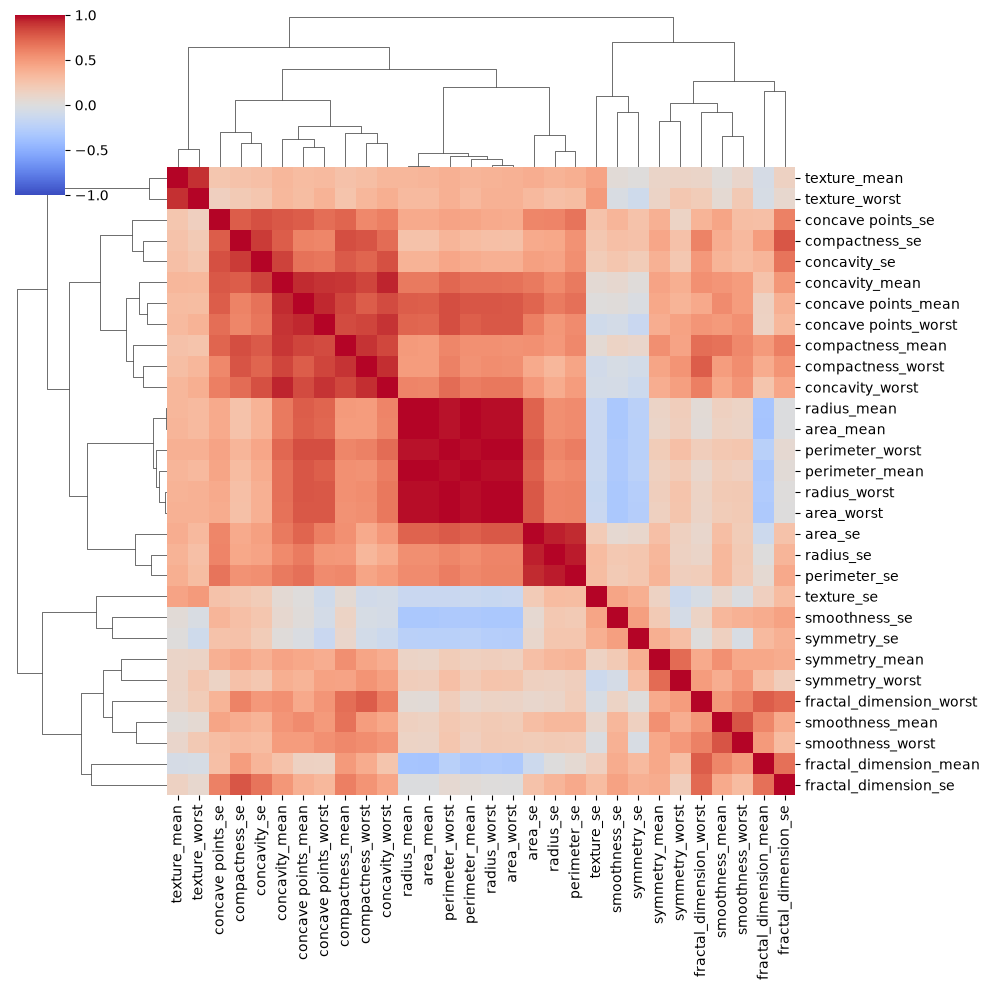

In [19]:
# Affichage des clusters de corrélations entre les variables
clustermap(
    correlations,
    cmap="coolwarm",      # Bleu à Rouge
    vmin=-1,    vmax=1    # Min et max standardisés
)

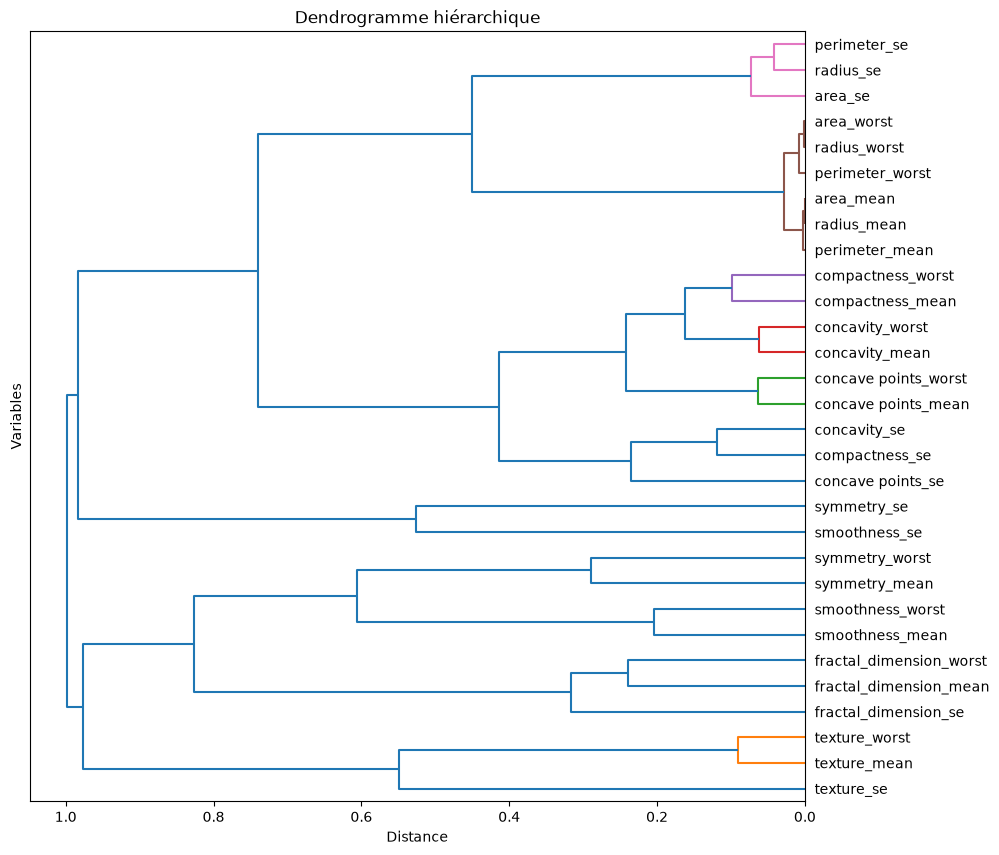

In [20]:
# Transformation des indices de correlation en distances
distances = 1 - correlations.abs()     # d = 1 - |ρ| 

# Seuil arbitraire (sera comparé à d'autres seuils à l'étape 4)
threshold = 0.1

condensed = squareform(X=distances)

# Création du clustering hierarchique
Z = linkage(condensed, method="complete")

# Affichage du dendogramme / Visualisation du clustering
plt.figure(figsize=(10, 10))

dendrogram(
    Z=Z, 
    labels=distances.columns, 
    orientation="left", 
    color_threshold=threshold 
)

plt.title('Dendrogramme hiérarchique')
plt.ylabel('Variables')
plt.xlabel('Distance')
plt.show()

In [21]:
# Récupération des groupes de variables
group_nbs = fcluster(Z=Z, criterion="distance", t=threshold)

# Conversion en DataFrame : une ligne par groupe, avec la liste de ses variables
groups = pd.Series(distances.columns, index=group_nbs, name="variables").groupby(level=0).agg(list).to_frame()

groups["count"] = groups["variables"].map(len)             # Décompte des variables par groupe
groups = groups.sort_values("count", ascending=False)       # Tri par la taille des groupes

# Verification
with pd.option_context("display.max_colwidth", None):
    display(groups)

,variables,count
18,"[radius_mean, perimeter_mean, area_mean, radius_worst, perimeter_worst, area_worst]",6
19,"[radius_se, perimeter_se, area_se]",3
1,"[texture_mean, texture_worst]",2
16,"[concavity_mean, concavity_worst]",2
15,"[concave points_mean, concave points_worst]",2
17,"[compactness_mean, compactness_worst]",2
2,[texture_se],1
3,[fractal_dimension_mean],1
4,[fractal_dimension_worst],1
6,[smoothness_mean],1


In [22]:
# Groupes contenant au moins 2 variables
multi_groups = groups.loc[groups["count"] > 1, "variables"]

# Liste des (sous-)matrices de corrélation, par groupe
matrixes = [correlations.abs().loc[cols, cols] for cols in multi_groups]

# Vérification
for m in matrixes:
    display(m)

,radius_mean,perimeter_mean,area_mean,radius_worst,perimeter_worst,area_worst
radius_mean,1.000000,0.997802,0.999602,0.978604,0.971555,0.978863
perimeter_mean,0.997802,1.000000,0.997068,0.981244,0.978980,0.980864
area_mean,0.999602,0.997068,1.000000,0.979258,0.971822,0.980264
radius_worst,0.978604,0.981244,0.979258,1.000000,0.993548,0.998891
perimeter_worst,0.971555,0.978980,0.971822,0.993548,1.000000,0.992433
area_worst,0.978863,0.980864,0.980264,0.998891,0.992433,1.000000


,radius_se,perimeter_se,area_se
radius_se,1.000000,0.957728,0.952867
perimeter_se,0.957728,1.000000,0.926937
area_se,0.952867,0.926937,1.000000


,texture_mean,texture_worst
texture_mean,1.000000,0.909218
texture_worst,0.909218,1.000000


,concavity_mean,concavity_worst
concavity_mean,1.000000,0.938543
concavity_worst,0.938543,1.000000


,concave points_mean,concave points_worst
concave points_mean,1.000000,0.937075
concave points_worst,0.937075,1.000000


,compactness_mean,compactness_worst
compactness_mean,1.000000,0.901029
compactness_worst,0.901029,1.000000


In [23]:
# Règle du représentant :
#   1. médoïde du groupe = plus forte |ρ| moyenne avec les autres membres
#   2. en cas d'égalité (toujours le cas pour une paire) : la variable la plus liée au diagnostic (|ρ| de Spearman avec Y_train)

# Corrélation l'indice de chaque variable avec la cible
target_corr = X.corrwith(Y, method="spearman").abs()

# Médoïde de chaque groupe
medoids = {}
for group, m in zip(multi_groups.index, matrixes):
    averages = (m.sum() - 1) / (m.shape[0] - 1)                 # Indice de corrélation moyen (diagonale retirée)
    ties = averages.index[np.isclose(averages, averages.max())] # Variable(s) ayant la moyenne maximale
    medoids[group] = target_corr[ties].idxmax()                 # Départage par le lien avec la cible

# Conversion de type
medoids = pd.Series(medoids, name="medoid")

# Vérification
medoids

18          perimeter_mean
19               radius_se
1            texture_worst
16          concavity_mean
15    concave points_worst
17        compactness_mean
Name: medoid, dtype: str

In [24]:
singletons = groups.loc[groups["count"] == 1, "variables"].str[0]   # Variables non fortement correlées
selected = list(medoids) + list(singletons)                         # Selection finale

# Vérification
print(f"{len(selected)} variables retenues sur {X.shape[1]}")
print(f"Avant : {(X.columns).to_list()}")
print(f"Après : {selected}")

19 variables retenues sur 30
Avant : ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Après : ['perimeter_mean', 'radius_se', 'texture_worst', 'concavity_mean', 'concave points_worst', 'compactness_mean', 'texture_se', 'fractal_dimension_mean', 'fractal_dimension_worst', 'smoothness_mean', 'fractal_dimension_se', 'symmetry_se', 'smoothness_se', 'symmetry_worst', 'symmetry_mean', 'smoothness_worst', 'concave points_se', 'compactness_se', 'concavity_se']


In [26]:
# Préparation à la sauvegarde 
X = X[selected]     # Filtrage sur les colonnes retenues
df = X.join(Y)    # Ajout de la colonne cible, alignée sur l'index

# Sauvergade
df.to_csv("./data/3-selected/data.csv", index=False)